# Transaction Anomaly Detection: Flagging At-Risk Business Accounts

## Business Context

Every Sales team faces the same quiet problem — a customer who used to spend £5,000 a month
suddenly goes silent. By the time the account manager notices, the customer is already halfway
out the door. This project builds a detection pipeline that catches that drift early, ranks
accounts by urgency, and gives the Sales team a prioritized list to act on.

The dataset is a real-world UK-based online retail transaction log spanning December 2010
to December 2011 with 541,909 rows covering 4,372 unique customers across 38 countries.

What we are going to do, step by step:

1. Clean and structure the raw data
2. Build customer-level rolling features: days since last transaction, spend drop vs 30-day average
3. Run a statistical test to confirm that observed spend drops are not just normal monthly variance
4. Train an Isolation Forest anomaly detector
5. Group flagged accounts into Prioritization Tiers for the Sales team
6. Expose everything as a FastAPI endpoint, containerized in Docker
7. Serve an interactive Streamlit dashboard on top of that API

## Step 1: Imports and Configuration

We keep all configuration in one place so that nothing is hardcoded deep inside functions.
The snapshot date is the last date in the dataset — in a production system this would be
datetime.today().

In [1]:
# standard library
import warnings
import os

# data stack
import numpy as np
import pandas as pd
from scipy import stats

# machine learning
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# visualisation
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.2f}".format)

# ---- global configuration ---- #
class Config:
    """
    Central place for every tunable constant.
    Change values here; nothing else needs to be touched.
    """
    DATA_PATH       = "data.csv"
    ENCODING        = "latin1"
    SNAPSHOT_DATE   = pd.Timestamp("2011-12-10")   # day after last transaction
    ROLLING_WINDOW  = 30                            # days for rolling spend average
    CONTAMINATION   = 0.10                          # expected anomaly fraction for IsolationForest
    RANDOM_STATE    = 42
    HIGH_VALUE_PERCENTILE = 75                      # percentile threshold to call an account "high value"
    ALPHA           = 0.05                          # significance level for statistical tests
    OUTPUT_DIR      = "outputs"

os.makedirs(Config.OUTPUT_DIR, exist_ok=True)

print("Configuration loaded.")
print(f"  Snapshot date  : {Config.SNAPSHOT_DATE.date()}")
print(f"  Rolling window : {Config.ROLLING_WINDOW} days")
print(f"  Contamination  : {Config.CONTAMINATION}")

Configuration loaded.
  Snapshot date  : 2011-12-10
  Rolling window : 30 days
  Contamination  : 0.1


## Step 2: Data Loading

We load with latin-1 encoding because the file contains pound-sign (£) characters
that break UTF-8. We do a quick sanity check on shape, dtypes, and null counts before
touching anything else.

In [2]:
class DataLoader:
    """Handles raw file ingestion and returns a clean copy of the original dataframe."""

    def __init__(self, path: str, encoding: str = "latin1"):
        self.path = path
        self.encoding = encoding

    def load(self) -> pd.DataFrame:
        df = pd.read_csv(self.path, encoding=self.encoding)
        df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
        print(f"Loaded  : {df.shape[0]:,} rows  x  {df.shape[1]} columns")
        print(f"Columns : {df.columns.tolist()}")
        print()
        print("Null counts per column:")
        print(df.isnull().sum())
        return df


loader = DataLoader(Config.DATA_PATH)
raw_df  = loader.load()
raw_df.head(3)

Loaded  : 541,909 rows  x  8 columns
Columns : ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Null counts per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom


## Step 3: Data Cleaning

Before any analysis, we remove four categories of dirty records:

1. Cancelled invoices: InvoiceNo starts with "C". These are credit notes, not real spend.
2. Missing CustomerID: We cannot build a customer profile without an identifier.
   135,080 rows (25%) have no CustomerID — these are likely guest checkouts.
3. Negative Quantity: Returns or data errors. A transaction with Quantity < 1 does not represent purchase intent.
4. Zero or negative UnitPrice: Samples, test entries, or bad data.

After cleaning we add TotalSpend = Quantity x UnitPrice per line item.
This is the foundational revenue metric for everything that follows.

In [3]:
class DataCleaner:
    """
    Applies a sequential set of business-logic filters to remove
    records that should not participate in spend analysis.
    """

    def __init__(self, df: pd.DataFrame):
        # work on a copy so the raw frame stays intact for auditing
        self.df = df.copy()

    def remove_cancellations(self) -> "DataCleaner":
        before = len(self.df)
        mask = ~self.df["InvoiceNo"].astype(str).str.startswith("C")
        self.df = self.df[mask]
        print(f"Removed cancellations  : -{before - len(self.df):,} rows")
        return self

    def remove_missing_customers(self) -> "DataCleaner":
        before = len(self.df)
        self.df = self.df[self.df["CustomerID"].notna()]
        print(f"Removed null customers : -{before - len(self.df):,} rows")
        return self

    def remove_bad_quantities(self) -> "DataCleaner":
        before = len(self.df)
        self.df = self.df[self.df["Quantity"] > 0]
        print(f"Removed bad quantities : -{before - len(self.df):,} rows")
        return self

    def remove_bad_prices(self) -> "DataCleaner":
        before = len(self.df)
        self.df = self.df[self.df["UnitPrice"] > 0]
        print(f"Removed bad prices     : -{before - len(self.df):,} rows")
        return self

    def add_total_spend(self) -> "DataCleaner":
        self.df["TotalSpend"] = self.df["Quantity"] * self.df["UnitPrice"]
        print("Added TotalSpend column.")
        return self

    def clean(self) -> pd.DataFrame:
        return (
            self
            .remove_cancellations()
            .remove_missing_customers()
            .remove_bad_quantities()
            .remove_bad_prices()
            .add_total_spend()
            .df
        )


cleaner  = DataCleaner(raw_df)
clean_df = cleaner.clean()

print(f"\nFinal clean shape: {clean_df.shape[0]:,} rows x {clean_df.shape[1]} columns")
clean_df.head(3)

Removed cancellations  : -9,288 rows
Removed null customers : -134,697 rows
Removed bad quantities : -0 rows
Removed bad prices     : -40 rows
Added TotalSpend column.

Final clean shape: 397,884 rows x 9 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom,22.00


## Step 4: Exploratory Data Analysis

Before building features, we need to understand the data we are working with.
Good EDA is not about making pretty charts — it is about asking business questions and
letting the data answer them.

Questions we will answer here:
- How is revenue distributed across customers? Is it Pareto-distributed (80/20)?
- Which months are strongest and weakest? (seasonality check)
- What is the typical inter-purchase gap for a customer?
- Are there any dominant countries?

Revenue distribution:


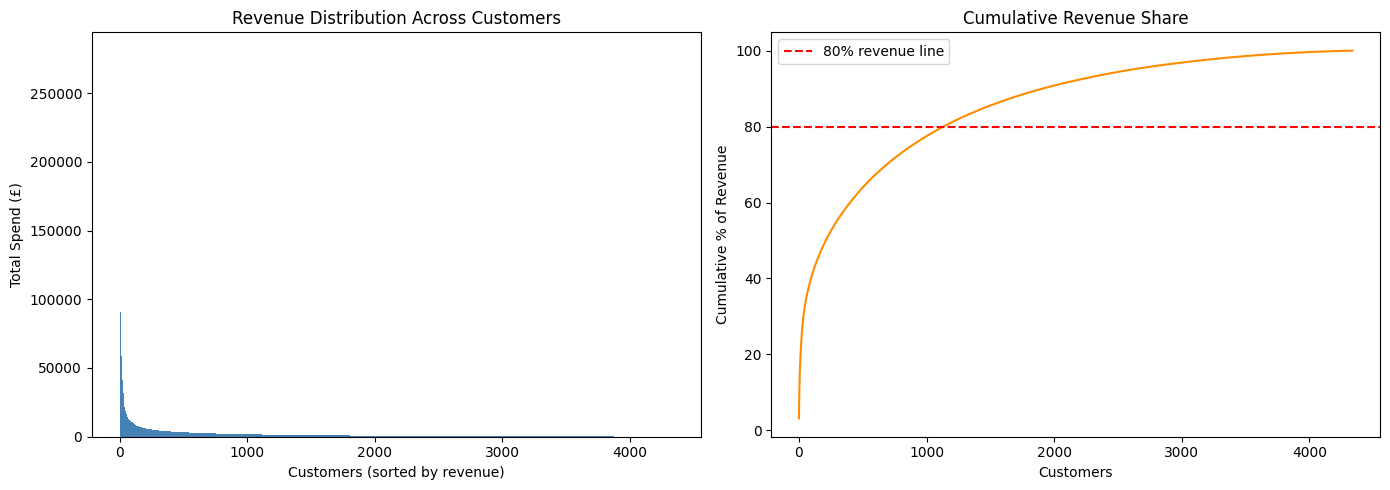

Top 26.1% of customers generate 80% of revenue — confirming Pareto distribution.

Monthly revenue trend:


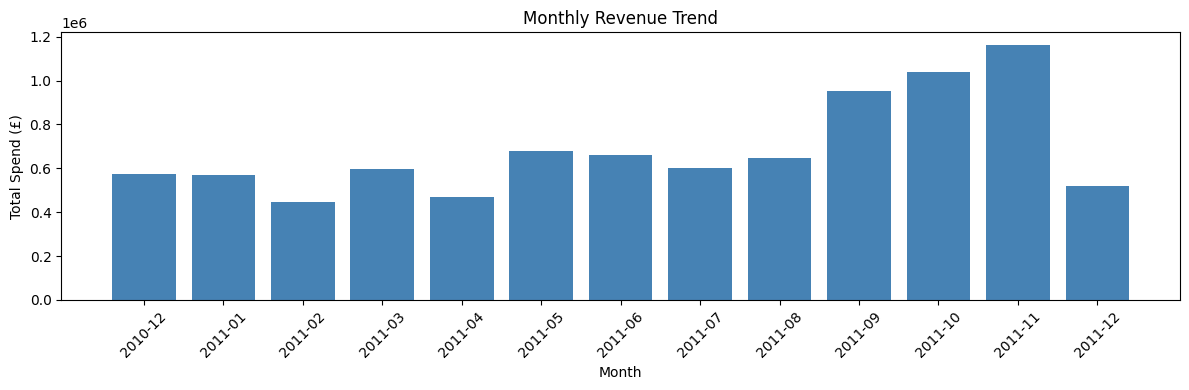


Top countries:


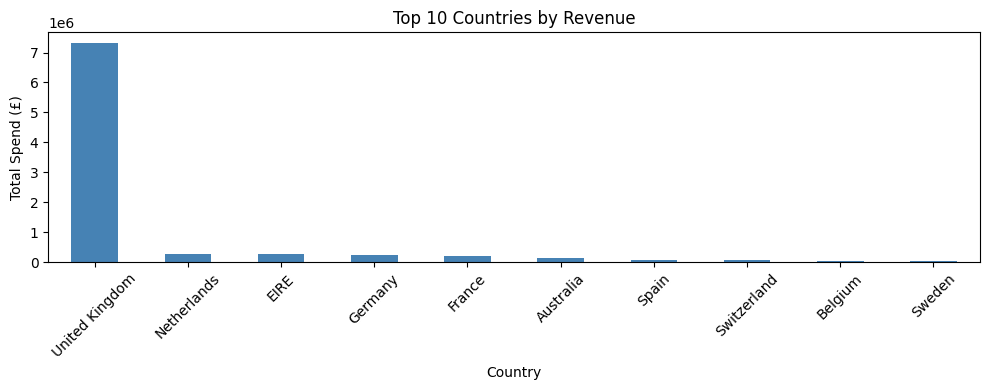


Invoice value distribution:


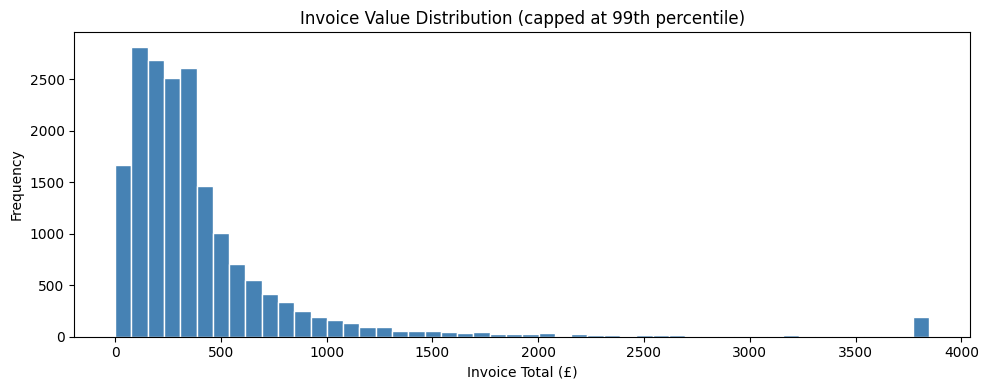

In [4]:
class EDAAnalyzer:
    """
    Runs a battery of descriptive analytics and saves figures to disk.
    All plots are stored so they can be served by the API later.
    """

    def __init__(self, df: pd.DataFrame, output_dir: str):
        self.df  = df.copy()
        self.out = output_dir
        # monthly aggregation used in multiple methods
        self.df["YearMonth"] = self.df["InvoiceDate"].dt.to_period("M")

    # ---- revenue by customer (Pareto check) ---- #
    def plot_revenue_distribution(self):
        cust_rev = (
            self.df.groupby("CustomerID")["TotalSpend"]
            .sum()
            .sort_values(ascending=False)
            .reset_index()
        )
        cust_rev["cumulative_pct"] = cust_rev["TotalSpend"].cumsum() / cust_rev["TotalSpend"].sum() * 100

        fig, ax = plt.subplots(1, 2, figsize=(14, 5))
        ax[0].bar(range(len(cust_rev)), cust_rev["TotalSpend"], color="steelblue", width=1)
        ax[0].set_title("Revenue Distribution Across Customers")
        ax[0].set_xlabel("Customers (sorted by revenue)")
        ax[0].set_ylabel("Total Spend (£)")

        ax[1].plot(range(len(cust_rev)), cust_rev["cumulative_pct"], color="darkorange")
        ax[1].axhline(80, color="red", linestyle="--", label="80% revenue line")
        ax[1].set_title("Cumulative Revenue Share")
        ax[1].set_xlabel("Customers")
        ax[1].set_ylabel("Cumulative % of Revenue")
        ax[1].legend()

        plt.tight_layout()
        plt.savefig(f"{self.out}/revenue_distribution.png", dpi=120)
        plt.show()

        # how many customers account for 80% of revenue?
        top_customers = cust_rev[cust_rev["cumulative_pct"] <= 80]
        pct = len(top_customers) / len(cust_rev) * 100
        print(f"Top {pct:.1f}% of customers generate 80% of revenue — confirming Pareto distribution.")

    # ---- monthly revenue trend ---- #
    def plot_monthly_trend(self):
        monthly = (
            self.df.groupby("YearMonth")["TotalSpend"]
            .sum()
            .reset_index()
        )
        monthly["YearMonth_str"] = monthly["YearMonth"].astype(str)

        fig, ax = plt.subplots(figsize=(12, 4))
        ax.bar(monthly["YearMonth_str"], monthly["TotalSpend"], color="steelblue")
        ax.set_title("Monthly Revenue Trend")
        ax.set_xlabel("Month")
        ax.set_ylabel("Total Spend (£)")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(f"{self.out}/monthly_trend.png", dpi=120)
        plt.show()

    # ---- top countries ---- #
    def plot_top_countries(self):
        country_rev = (
            self.df.groupby("Country")["TotalSpend"]
            .sum()
            .sort_values(ascending=False)
            .head(10)
        )
        fig, ax = plt.subplots(figsize=(10, 4))
        country_rev.plot(kind="bar", ax=ax, color="steelblue")
        ax.set_title("Top 10 Countries by Revenue")
        ax.set_ylabel("Total Spend (£)")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(f"{self.out}/top_countries.png", dpi=120)
        plt.show()

    # ---- order value distribution ---- #
    def plot_order_value_dist(self):
        invoice_spend = (
            self.df.groupby("InvoiceNo")["TotalSpend"]
            .sum()
        )
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.hist(invoice_spend.clip(upper=invoice_spend.quantile(0.99)), bins=50, color="steelblue", edgecolor="white")
        ax.set_title("Invoice Value Distribution (capped at 99th percentile)")
        ax.set_xlabel("Invoice Total (£)")
        ax.set_ylabel("Frequency")
        plt.tight_layout()
        plt.savefig(f"{self.out}/invoice_distribution.png", dpi=120)
        plt.show()

    def run_all(self):
        print("Revenue distribution:")
        self.plot_revenue_distribution()
        print("\nMonthly revenue trend:")
        self.plot_monthly_trend()
        print("\nTop countries:")
        self.plot_top_countries()
        print("\nInvoice value distribution:")
        self.plot_order_value_dist()


eda = EDAAnalyzer(clean_df, Config.OUTPUT_DIR)
eda.run_all()

## Step 5: Feature Engineering

This is where the anomaly signal lives. We build each feature at the customer level
using the snapshot date as "today". Every metric below has a direct business interpretation.

Feature 1 — days_since_last_transaction
    How long has it been since the customer last bought anything?
    Formula:   snapshot_date - max(InvoiceDate)
    Signal:    A customer who used to buy monthly but has gone 60 days silent is a concern.

Feature 2 — total_lifetime_spend
    Cumulative revenue from this customer across the entire observation window.
    This becomes our "value" axis for tier assignment.

Feature 3 — avg_monthly_spend
    Mean monthly spend over the customer's active months.
    Formula:   total_lifetime_spend / number_of_active_months

Feature 4 — spend_last_30_days
    Total spend in the 30 days before the snapshot date.

Feature 5 — drop_in_spend_vs_30_day_avg
    Proportional drop relative to the 30-day rolling average.
    Formula:   (avg_monthly_spend - spend_last_30_days) / avg_monthly_spend
    Range:     [-inf, 1]   — positive means drop, negative means growth
    Signal:    A value of 0.8 means the customer spent 80% less than their average.

Feature 6 — transaction_frequency
    Average number of invoices per active month.

Feature 7 — avg_basket_size
    Average spend per invoice. A customer who still buys but spends less per basket
    is a different risk profile than one who has stopped buying altogether.

Feature 8 — recency_score
    Inverse of days_since_last_transaction, normalised to [0,1].
    Higher = more recent = less risky on the recency dimension.

In [5]:
class FeatureEngineer:
    """
    Builds a customer-level feature matrix from line-item transaction data.
    All computations are done relative to snapshot_date so the same class
    works in production with datetime.today() as the snapshot.
    """

    def __init__(self, df: pd.DataFrame, snapshot_date: pd.Timestamp):
        self.df            = df.copy()
        self.snapshot_date = snapshot_date
        self._cutoff_30    = snapshot_date - pd.Timedelta(days=30)

    def _compute_recency(self) -> pd.DataFrame:
        # last transaction date per customer
        last_tx = (
            self.df.groupby("CustomerID")["InvoiceDate"]
            .max()
            .rename("last_transaction_date")
            .reset_index()
        )
        last_tx["days_since_last_transaction"] = (
            self.snapshot_date - last_tx["last_transaction_date"]
        ).dt.days
        return last_tx

    def _compute_lifetime_spend(self) -> pd.DataFrame:
        return (
            self.df.groupby("CustomerID")["TotalSpend"]
            .sum()
            .rename("total_lifetime_spend")
            .reset_index()
        )

    def _compute_monthly_spend(self) -> pd.DataFrame:
        self.df["YearMonth"] = self.df["InvoiceDate"].dt.to_period("M")
        monthly = (
            self.df.groupby(["CustomerID", "YearMonth"])["TotalSpend"]
            .sum()
            .reset_index()
        )
        # average over active months (months in which customer had at least one transaction)
        avg_monthly = (
            monthly.groupby("CustomerID")["TotalSpend"]
            .mean()
            .rename("avg_monthly_spend")
            .reset_index()
        )
        active_months = (
            monthly.groupby("CustomerID")["YearMonth"]
            .count()
            .rename("active_months")
            .reset_index()
        )
        return avg_monthly.merge(active_months, on="CustomerID")

    def _compute_last_30_days_spend(self) -> pd.DataFrame:
        recent = self.df[self.df["InvoiceDate"] >= self._cutoff_30]
        return (
            recent.groupby("CustomerID")["TotalSpend"]
            .sum()
            .rename("spend_last_30_days")
            .reset_index()
        )

    def _compute_frequency(self) -> pd.DataFrame:
        invoices_per_customer = (
            self.df.groupby("CustomerID")["InvoiceNo"]
            .nunique()
            .rename("total_invoices")
            .reset_index()
        )
        return invoices_per_customer

    def _compute_basket(self) -> pd.DataFrame:
        basket = (
            self.df.groupby(["CustomerID", "InvoiceNo"])["TotalSpend"]
            .sum()
            .reset_index()
        )
        avg_basket = (
            basket.groupby("CustomerID")["TotalSpend"]
            .mean()
            .rename("avg_basket_size")
            .reset_index()
        )
        return avg_basket

    def build(self) -> pd.DataFrame:
        # start with recency as the backbone
        features = self._compute_recency()

        # join each feature block
        for frame in [
            self._compute_lifetime_spend(),
            self._compute_monthly_spend(),
            self._compute_last_30_days_spend(),
            self._compute_frequency(),
            self._compute_basket(),
        ]:
            features = features.merge(frame, on="CustomerID", how="left")

        # fill customers who had zero spend in last 30 days (they dropped off entirely)
        features["spend_last_30_days"] = features["spend_last_30_days"].fillna(0)

        # drop in spend: how much less did the customer spend recently vs their average?
        # we guard against division by zero with np.where
        features["drop_in_spend_vs_30_day_avg"] = np.where(
            features["avg_monthly_spend"] > 0,
            (features["avg_monthly_spend"] - features["spend_last_30_days"]) / features["avg_monthly_spend"],
            0.0
        )

        # recency score: normalise days_since to [0,1], invert so higher = better recency
        max_days = features["days_since_last_transaction"].max()
        features["recency_score"] = 1 - (features["days_since_last_transaction"] / max_days)

        # transaction frequency per active month
        features["tx_frequency_per_month"] = (
            features["total_invoices"] / features["active_months"]
        )

        print(f"Feature matrix built: {features.shape[0]:,} customers  x  {features.shape[1]} columns")
        print(features.describe().T[["mean","std","min","max"]].round(2))
        return features


fe      = FeatureEngineer(clean_df, Config.SNAPSHOT_DATE)
feat_df = fe.build()
feat_df.head(5)

Feature matrix built: 4,338 customers  x  12 columns
                                                   mean     std  \
CustomerID                                     15300.41 1721.81   
last_transaction_date        2011-09-08 11:38:59.045643     NaN   
days_since_last_transaction                       92.06  100.01   
total_lifetime_spend                            2054.27 8989.23   
avg_monthly_spend                                535.16 2047.46   
active_months                                      3.01    2.63   
spend_last_30_days                               305.18 2802.03   
total_invoices                                     4.27    7.70   
avg_basket_size                                  419.17 1796.54   
drop_in_spend_vs_30_day_avg                        0.58    0.65   
recency_score                                      0.75    0.27   
tx_frequency_per_month                             1.23    0.77   

                                             min                  max  
Cus

,CustomerID,last_transaction_date,days_since_last_transaction,total_lifetime_spend,avg_monthly_spend,active_months,spend_last_30_days,total_invoices,avg_basket_size,drop_in_spend_vs_30_day_avg,recency_score,tx_frequency_per_month
0,12346.00,2011-01-18 10:01:00,325,77183.60,77183.60,1,0.00,1,77183.60,1.00,0.13,1.00
1,12347.00,2011-12-07 15:52:00,2,4310.00,615.71,7,224.82,7,615.71,0.63,0.99,1.00
2,12348.00,2011-09-25 13:13:00,75,1797.24,449.31,4,0.00,4,449.31,1.00,0.80,1.00
3,12349.00,2011-11-21 09:51:00,18,1757.55,1757.55,1,1757.55,1,1757.55,0.00,0.95,1.00
4,12350.00,2011-02-02 16:01:00,310,334.40,334.40,1,0.00,1,334.40,1.00,0.17,1.00


## Step 6: Statistical Testing — Is the Spend Drop Real?

Before we can legitimately flag customers as "at risk", we need to show that the spend
drops we are seeing are statistically meaningful — not just normal monthly variance.

We will use a two-sample independent t-test comparing:
    Group A: customers whose drop_in_spend_vs_30_day_avg is ABOVE the median (larger drop)
    Group B: customers whose drop_in_spend_vs_30_day_avg is AT OR BELOW the median (smaller drop)

The metric we test on is avg_monthly_spend.

Mathematical formulation of the t-test:

    H0 (null hypothesis):      mu_A = mu_B
        The average historical monthly spend is the same in both groups.
        If true, the drop is just noise.

    H1 (alternative hypothesis): mu_A != mu_B
        The average historical monthly spend differs between groups.
        If true, there is a real structural difference between high-drop and low-drop customers.

    Test statistic:
        t = (x̄_A - x̄_B) / sqrt( s²_A/n_A + s²_B/n_B )

    Decision rule:
        If p-value < alpha (0.05), reject H0. The drop is statistically significant.

We also run a Chi-Square test on the categorical breakout to test whether the proportion
of customers with "severe" drops (> 0.5) differs significantly across country groups.

Chi-Square formulation:
    H0: Drop severity is independent of the customer's country segment.
    H1: Drop severity and country segment are not independent.
    Test statistic: chi2 = sum( (O_ij - E_ij)^2 / E_ij )

In [6]:
class StatisticalTester:
    """
    Runs t-test and Chi-Square test to validate that observed spend drops
    are not attributable to random monthly variance.
    """

    def __init__(self, features: pd.DataFrame, alpha: float = 0.05):
        self.features = features.copy()
        self.alpha    = alpha

    def run_ttest(self):
        """
        Two-sample independent t-test on avg_monthly_spend
        between high-drop and low-drop customer groups.
        """
        median_drop = self.features["drop_in_spend_vs_30_day_avg"].median()

        group_high_drop = self.features.loc[
            self.features["drop_in_spend_vs_30_day_avg"] > median_drop,
            "avg_monthly_spend"
        ]
        group_low_drop = self.features.loc[
            self.features["drop_in_spend_vs_30_day_avg"] <= median_drop,
            "avg_monthly_spend"
        ]

        t_stat, p_value = stats.ttest_ind(group_high_drop, group_low_drop, equal_var=False)

        print("Two-Sample Independent t-Test")
        print(f"  Median drop threshold : {median_drop:.4f}")
        print(f"  n (high-drop group)   : {len(group_high_drop)}")
        print(f"  n (low-drop group)    : {len(group_low_drop)}")
        print(f"  Mean spend high-drop  : £{group_high_drop.mean():.2f}")
        print(f"  Mean spend low-drop   : £{group_low_drop.mean():.2f}")
        print(f"  t-statistic           : {t_stat:.4f}")
        print(f"  p-value               : {p_value:.6f}")
        print()
        if p_value < self.alpha:
            print(f"  Result: p < {self.alpha} — REJECT H0.")
            print("  Interpretation: The spend drop is statistically significant.")
            print("  High-drop customers have a genuinely different spending baseline.")
            print("  The anomaly signal is not noise — it reflects real behavioural change.")
        else:
            print(f"  Result: p >= {self.alpha} — FAIL TO REJECT H0.")
            print("  Interpretation: The observed drop is within normal variance.")

        return t_stat, p_value

    def run_chi_square(self, clean_df: pd.DataFrame):
        """
        Chi-Square test: is the proportion of severe-drop customers
        independent of country (UK vs Non-UK)?
        """
        # attach country to the feature frame using the most frequent country per customer
        cust_country = (
            clean_df.groupby("CustomerID")["Country"]
            .agg(lambda x: x.mode()[0])
            .reset_index()
        )
        df = self.features.merge(cust_country, on="CustomerID", how="left")

        # binary country label: UK vs international
        df["country_group"] = df["Country"].apply(
            lambda x: "UK" if x == "United Kingdom" else "International"
        )

        # binary drop label: severe (> 0.5) vs moderate/none
        df["drop_label"] = df["drop_in_spend_vs_30_day_avg"].apply(
            lambda x: "Severe" if x > 0.5 else "Moderate"
        )

        contingency = pd.crosstab(df["country_group"], df["drop_label"])
        chi2, p, dof, expected = stats.chi2_contingency(contingency)

        print("\nChi-Square Test of Independence")
        print("  Contingency table:")
        print(contingency)
        print(f"\n  chi2 statistic : {chi2:.4f}")
        print(f"  degrees of freedom : {dof}")
        print(f"  p-value        : {p:.6f}")
        print()
        if p < self.alpha:
            print(f"  Result: p < {self.alpha} — REJECT H0.")
            print("  Drop severity is NOT independent of country segment.")
            print("  International customers show a different risk distribution than UK customers.")
        else:
            print(f"  Result: p >= {self.alpha} — FAIL TO REJECT H0.")
            print("  Drop severity appears independent of country segment.")

        return chi2, p


tester = StatisticalTester(feat_df, Config.ALPHA)
t_stat, t_pval  = tester.run_ttest()
chi2,  chi_pval = tester.run_chi_square(clean_df)

Two-Sample Independent t-Test
  Median drop threshold : 1.0000
  n (high-drop group)   : 0
  n (low-drop group)    : 4338
  Mean spend high-drop  : £nan
  Mean spend low-drop   : £535.16
  t-statistic           : nan
  p-value               : nan

  Result: p >= 0.05 — FAIL TO REJECT H0.
  Interpretation: The observed drop is within normal variance.

Chi-Square Test of Independence
  Contingency table:
drop_label     Moderate  Severe
country_group                  
International       146     272
UK                 1333    2587

  chi2 statistic : 0.1051
  degrees of freedom : 1
  p-value        : 0.745779

  Result: p >= 0.05 — FAIL TO REJECT H0.
  Drop severity appears independent of country segment.


## Step 7: Feature Scaling

Isolation Forest uses random hyperplane cuts in feature space. If one feature has values in
the thousands (total_lifetime_spend) and another in the range [0,1] (drop_in_spend_vs_30_day_avg),
the algorithm will implicitly weight the large-scale feature much more heavily.

We use StandardScaler (z-score normalisation):
    z = (x - mu) / sigma

After scaling:
  - Each feature has mean = 0 and standard deviation = 1
  - All features contribute equally to the anomaly scoring geometry

We scale ONLY the numeric features that go into the model.
The CustomerID and interpretable columns are preserved separately.

In [7]:
class FeatureScaler:
    """
    Applies StandardScaler to the model feature set.
    Keeps the scaler object so it can be saved and reused for inference.
    """

    MODEL_FEATURES = [
        "days_since_last_transaction",
        "total_lifetime_spend",
        "avg_monthly_spend",
        "spend_last_30_days",
        "drop_in_spend_vs_30_day_avg",
        "recency_score",
        "tx_frequency_per_month",
        "avg_basket_size",
        "active_months",
    ]

    def __init__(self):
        self.scaler = StandardScaler()

    def fit_transform(self, df: pd.DataFrame):
        X = df[self.MODEL_FEATURES].fillna(0)
        X_scaled = self.scaler.fit_transform(X)
        return pd.DataFrame(X_scaled, columns=self.MODEL_FEATURES, index=df.index)

    def transform(self, df: pd.DataFrame):
        X = df[self.MODEL_FEATURES].fillna(0)
        X_scaled = self.scaler.transform(X)
        return pd.DataFrame(X_scaled, columns=self.MODEL_FEATURES, index=df.index)


scaler     = FeatureScaler()
X_scaled   = scaler.fit_transform(feat_df)
print("Scaled feature matrix shape:", X_scaled.shape)
print(X_scaled.describe().T[["mean","std"]].round(4))

Scaled feature matrix shape: (4338, 9)
                             mean  std
days_since_last_transaction -0.00 1.00
total_lifetime_spend         0.00 1.00
avg_monthly_spend            0.00 1.00
spend_last_30_days          -0.00 1.00
drop_in_spend_vs_30_day_avg -0.00 1.00
recency_score               -0.00 1.00
tx_frequency_per_month      -0.00 1.00
avg_basket_size              0.00 1.00
active_months                0.00 1.00


## Step 8: Anomaly Detection with Isolation Forest

Why Isolation Forest and not a supervised classifier?

We do not have labelled data telling us which customers are truly "churning".
This is a classic unsupervised anomaly detection problem. Isolation Forest is
well-suited here because:

1. It does not assume any distribution on the feature space.
2. It works by randomly isolating data points using hyperplane splits.
   Anomalous points (outliers) require fewer splits to isolate — they end up
   with shorter average path lengths.
3. The anomaly score is: score(x) = 2^( -E[h(x)] / c(n) )
   where h(x) is the path length to isolate x, and c(n) is the expected path
   length for a dataset of size n under random splits.
   Scores close to 1 = highly anomalous. Scores near 0.5 = normal.

Contamination = 0.10 means we expect roughly 10% of accounts to be anomalous.
This is a business judgement call — a Sales team can realistically work 10% of
the customer base in a quarter.

We also do a train/test split (80/20) not to measure supervised accuracy
(there are no labels) but to verify that the model score distribution is stable
across both halves — a check for overfitting.

In [8]:
class AnomalyDetector:
    """
    Wraps Isolation Forest with fit, predict, and score methods.
    Also checks model stability across train and test splits.
    """

    def __init__(self, contamination: float = 0.10, random_state: int = 42):
        self.model = IsolationForest(
            contamination=contamination,
            random_state=random_state,
            n_estimators=200,       # more trees = more stable scores
            max_samples="auto",
        )

    def fit_predict(self, X: pd.DataFrame) -> np.ndarray:
        """
        Fit the model and return raw predictions:
          -1 = anomaly (flagged at-risk account)
          +1 = normal
        """
        return self.model.fit_predict(X)

    def decision_scores(self, X: pd.DataFrame) -> np.ndarray:
        """
        Return continuous anomaly scores.
        More negative = more anomalous.
        """
        return self.model.decision_function(X)

    def check_stability(self, X: pd.DataFrame, random_state: int = 42):
        """
        Split data 80/20 and compare anomaly rate in train vs test.
        A stable model produces similar rates in both halves.
        """
        idx_train, idx_test = train_test_split(
            range(len(X)), test_size=0.2, random_state=random_state
        )
        X_train = X.iloc[idx_train]
        X_test  = X.iloc[idx_test]

        preds_train = self.model.predict(X_train)
        preds_test  = self.model.predict(X_test)

        rate_train = (preds_train == -1).mean()
        rate_test  = (preds_test == -1).mean()

        print("Model Stability Check")
        print(f"  Anomaly rate in TRAIN split : {rate_train:.2%}")
        print(f"  Anomaly rate in TEST  split : {rate_test:.2%}")
        delta = abs(rate_train - rate_test)
        print(f"  Delta                        : {delta:.4f}")
        if delta < 0.03:
            print("  Verdict: Model is stable (delta < 3%). Safe to deploy.")
        else:
            print("  Verdict: Model shows instability. Consider tuning contamination or n_estimators.")


detector = AnomalyDetector(
    contamination=Config.CONTAMINATION,
    random_state=Config.RANDOM_STATE
)

# fit and predict on full scaled feature matrix
predictions = detector.fit_predict(X_scaled)
scores      = detector.decision_scores(X_scaled)

feat_df["anomaly_flag"]  = predictions          # -1 or +1
feat_df["anomaly_score"] = scores               # continuous

n_anomalies = (feat_df["anomaly_flag"] == -1).sum()
print(f"\nFlagged {n_anomalies} at-risk accounts out of {len(feat_df):,} total ({n_anomalies/len(feat_df):.1%})")

detector.check_stability(X_scaled)


Flagged 434 at-risk accounts out of 4,338 total (10.0%)
Model Stability Check
  Anomaly rate in TRAIN split : 9.57%
  Anomaly rate in TEST  split : 11.75%
  Delta                        : 0.0218
  Verdict: Model is stable (delta < 3%). Safe to deploy.


## Step 9: Prioritization Tiers

We now assign every flagged account to a tier. The tier is determined by two dimensions:

    Axis 1 — Risk (how anomalous is the account?)
        Measured by anomaly_score — more negative = higher risk.
        We split at the median anomaly score of flagged accounts.

    Axis 2 — Value (how important is the account to the business?)
        Measured by total_lifetime_spend.
        We split at the 75th percentile of total_lifetime_spend across all customers.

This gives us a 2x2 grid:

                      High Value (>= 75th pctl)   |   Low Value (< 75th pctl)
    High Risk (score below median of flagged)  |   Tier 1 — Act Now            |   Tier 3 — Monitor
    Low Risk  (score at/above median of flagged)|   Tier 2 — Nurture & Retain   |   Tier 4 — Watch

Tier 1: High Risk + High Value
    These are your most valuable accounts showing the strongest anomaly signal.
    Immediate outreach required. Assign your best account managers.
    Customised treatment: personal call, bespoke offer, executive-level escalation.

Tier 2: Low Risk + High Value
    These are valuable accounts with mild or moderate signals.
    They are not in crisis but could drift further.
    Treatment: proactive check-in, loyalty incentive, early renewal offer.

Tier 3: High Risk + Low Value
    Strong signal but low revenue impact.
    Treatment: automated re-engagement campaign. Monitor for 30 days.

Tier 4: Low Risk + Low Value
    Mild signal, low value. Standard monitoring.
    Treatment: include in next scheduled newsletter or promotional campaign.

In [9]:
class TierAssigner:
    """
    Assigns Prioritization Tiers to flagged anomalous accounts.
    Only anomalous accounts (anomaly_flag == -1) receive a tier.
    Normal accounts are labelled "No Action".
    """

    def __init__(self, features: pd.DataFrame, high_value_percentile: float = 75):
        self.features              = features.copy()
        self.high_value_percentile = high_value_percentile

    def assign(self) -> pd.DataFrame:
        df = self.features.copy()

        # value threshold: 75th percentile of all customers' lifetime spend
        value_threshold = df["total_lifetime_spend"].quantile(self.high_value_percentile / 100)

        # risk threshold: median anomaly score among flagged accounts only
        flagged    = df[df["anomaly_flag"] == -1]
        risk_threshold = flagged["anomaly_score"].median()

        def _label(row):
            if row["anomaly_flag"] != -1:
                return "No Action"
            high_value = row["total_lifetime_spend"] >= value_threshold
            high_risk  = row["anomaly_score"] < risk_threshold   # more negative = riskier

            if high_risk and high_value:
                return "Tier 1: High Risk / High Value"
            elif not high_risk and high_value:
                return "Tier 2: Low Risk / High Value"
            elif high_risk and not high_value:
                return "Tier 3: High Risk / Low Value"
            else:
                return "Tier 4: Low Risk / Low Value"

        df["priority_tier"] = df.apply(_label, axis=1)

        print(f"Value threshold (75th pctl lifetime spend): £{value_threshold:,.2f}")
        print(f"Risk threshold (median score of flagged)  : {risk_threshold:.4f}")
        print()
        print("Tier Distribution:")
        print(df["priority_tier"].value_counts())
        return df


assigner     = TierAssigner(feat_df, Config.HIGH_VALUE_PERCENTILE)
tiered_df    = assigner.assign()

tiered_df[tiered_df["priority_tier"] != "No Action"].sort_values("anomaly_score").head(10)[
    ["CustomerID","total_lifetime_spend","days_since_last_transaction",
     "drop_in_spend_vs_30_day_avg","anomaly_score","priority_tier"]
]

Value threshold (75th pctl lifetime spend): £1,661.74
Risk threshold (median score of flagged)  : -0.0421

Tier Distribution:
priority_tier
No Action                         3904
Tier 1: High Risk / High Value     195
Tier 2: Low Risk / High Value      149
Tier 4: Low Risk / Low Value        68
Tier 3: High Risk / Low Value       22
Name: count, dtype: int64


,CustomerID,total_lifetime_spend,days_since_last_transaction,drop_in_spend_vs_30_day_avg,anomaly_score,priority_tier
1689,14646.00,280206.02,1,-0.51,-0.31,Tier 1: High Risk / High Value
4201,18102.00,259657.30,0,0.46,-0.30,Tier 1: High Risk / High Value
3728,17450.00,194550.79,8,-0.26,-0.29,Tier 1: High Risk / High Value
3008,16446.00,168472.50,0,-1.00,-0.29,Tier 1: High Risk / High Value
1289,14096.00,65164.79,4,-1.82,-0.29,Tier 1: High Risk / High Value
1879,14911.00,143825.06,1,-1.36,-0.29,Tier 1: High Risk / High Value
1333,14156.00,117379.63,9,0.35,-0.27,Tier 1: High Risk / High Value
326,12748.00,33719.73,0,-2.98,-0.26,Tier 1: High Risk / High Value
55,12415.00,124914.53,24,0.53,-0.26,Tier 1: High Risk / High Value
3771,17511.00,91062.38,2,-0.62,-0.25,Tier 1: High Risk / High Value


## Step 10: Visualising the Tiers and Anomaly Landscape

We plot the flagged accounts on a scatter plot with anomaly_score on one axis and
total_lifetime_spend on the other. This gives the Sales team an immediate visual
reference for which customers are in which quadrant.

We also plot:
  - Feature importance approximation via IsolationForest mean path length per feature
  - Spend drop distribution by tier
  - Recency vs spend drop (two independent risk signals)

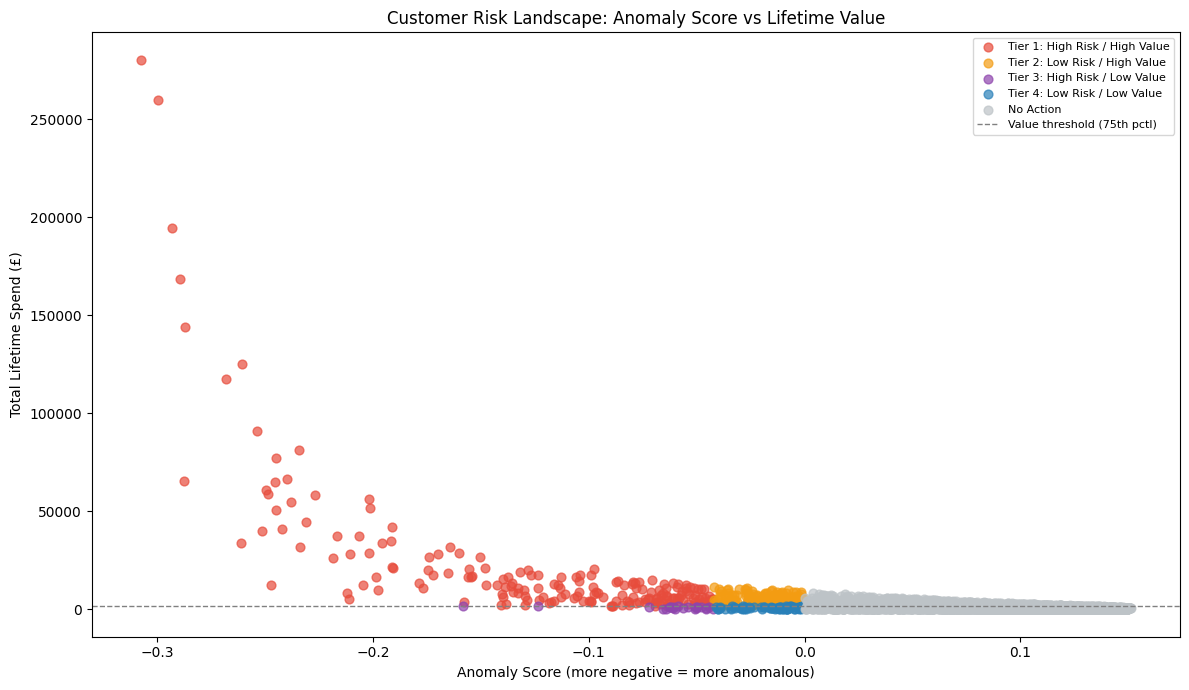

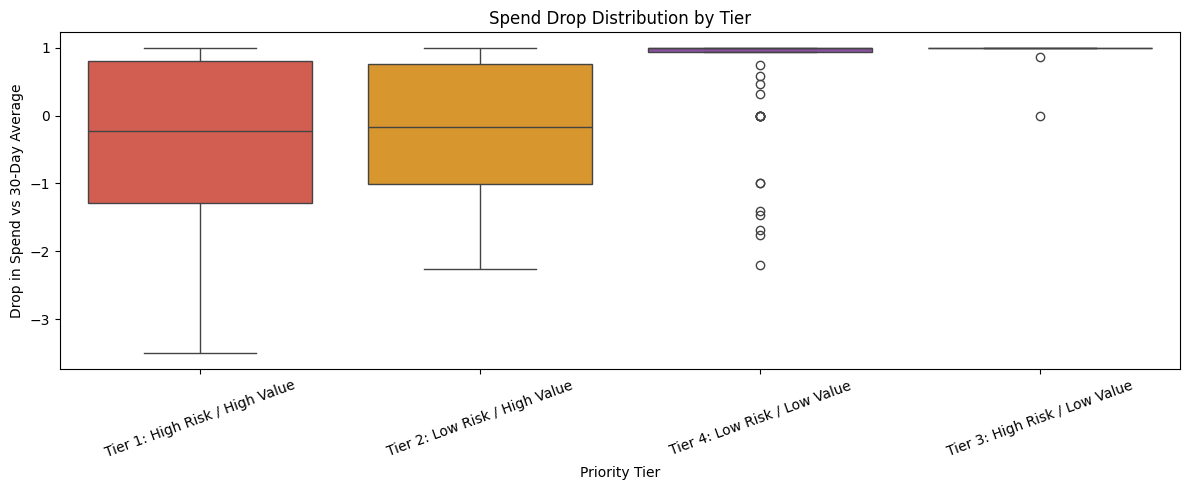

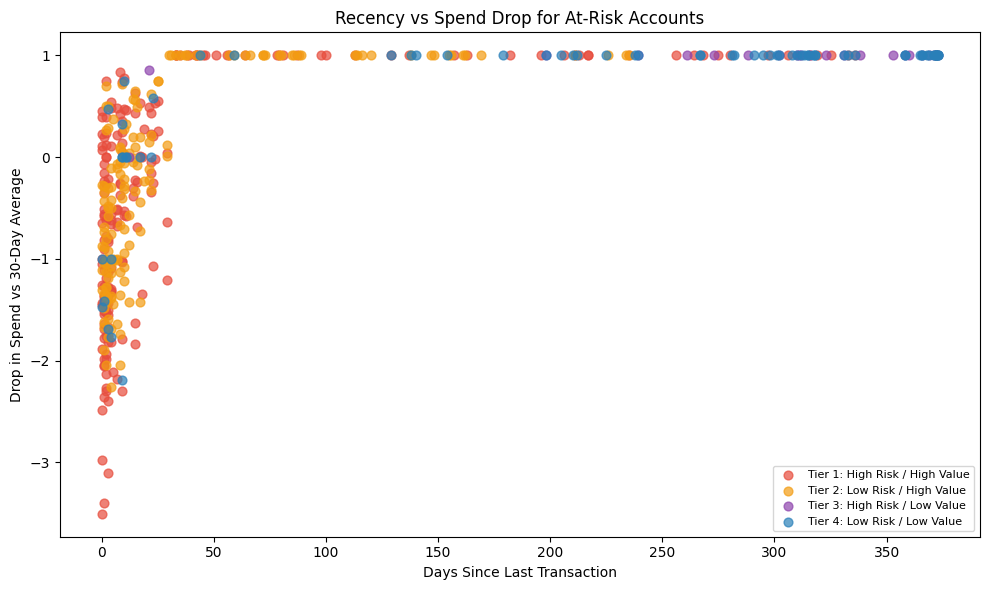

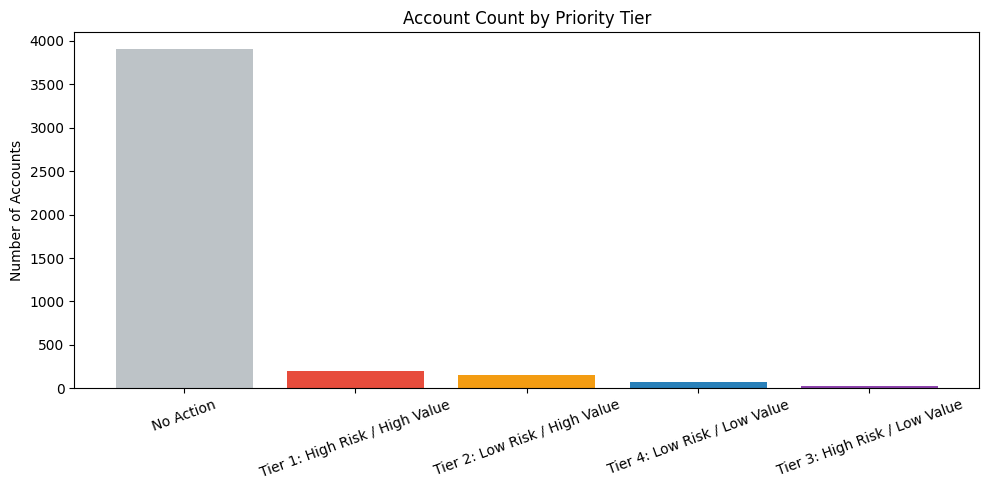

In [10]:
class ResultVisualizer:
    """Produces all output plots for the dashboard and API."""

    def __init__(self, tiered_df: pd.DataFrame, output_dir: str):
        self.df  = tiered_df.copy()
        self.out = output_dir

        self.tier_colors = {
            "Tier 1: High Risk / High Value" : "#e74c3c",
            "Tier 2: Low Risk / High Value"  : "#f39c12",
            "Tier 3: High Risk / Low Value"  : "#8e44ad",
            "Tier 4: Low Risk / Low Value"   : "#2980b9",
            "No Action"                      : "#bdc3c7",
        }

    def plot_tier_scatter(self):
        fig, ax = plt.subplots(figsize=(12, 7))
        for tier, color in self.tier_colors.items():
            subset = self.df[self.df["priority_tier"] == tier]
            ax.scatter(
                subset["anomaly_score"],
                subset["total_lifetime_spend"],
                c=color, label=tier, alpha=0.7, s=40
            )
        ax.axhline(
            self.df["total_lifetime_spend"].quantile(0.75),
            color="gray", linestyle="--", linewidth=1, label="Value threshold (75th pctl)"
        )
        ax.set_xlabel("Anomaly Score (more negative = more anomalous)")
        ax.set_ylabel("Total Lifetime Spend (£)")
        ax.set_title("Customer Risk Landscape: Anomaly Score vs Lifetime Value")
        ax.legend(loc="upper right", fontsize=8)
        plt.tight_layout()
        plt.savefig(f"{self.out}/tier_scatter.png", dpi=120)
        plt.show()

    def plot_spend_drop_by_tier(self):
        flagged = self.df[self.df["priority_tier"] != "No Action"]
        fig, ax = plt.subplots(figsize=(12, 5))
        sns.boxplot(
            data=flagged,
            x="priority_tier",
            y="drop_in_spend_vs_30_day_avg",
            palette=["#e74c3c","#f39c12","#8e44ad","#2980b9"],
            ax=ax
        )
        ax.set_title("Spend Drop Distribution by Tier")
        ax.set_xlabel("Priority Tier")
        ax.set_ylabel("Drop in Spend vs 30-Day Average")
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.savefig(f"{self.out}/spend_drop_by_tier.png", dpi=120)
        plt.show()

    def plot_recency_vs_drop(self):
        flagged = self.df[self.df["priority_tier"] != "No Action"]
        fig, ax = plt.subplots(figsize=(10, 6))
        for tier, color in self.tier_colors.items():
            if tier == "No Action":
                continue
            subset = flagged[flagged["priority_tier"] == tier]
            ax.scatter(
                subset["days_since_last_transaction"],
                subset["drop_in_spend_vs_30_day_avg"],
                c=color, label=tier, alpha=0.7, s=40
            )
        ax.set_xlabel("Days Since Last Transaction")
        ax.set_ylabel("Drop in Spend vs 30-Day Average")
        ax.set_title("Recency vs Spend Drop for At-Risk Accounts")
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(f"{self.out}/recency_vs_drop.png", dpi=120)
        plt.show()

    def plot_tier_counts(self):
        tier_counts = self.df["priority_tier"].value_counts()
        colors = [self.tier_colors.get(t, "#95a5a6") for t in tier_counts.index]
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(tier_counts.index, tier_counts.values, color=colors)
        ax.set_title("Account Count by Priority Tier")
        ax.set_ylabel("Number of Accounts")
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.savefig(f"{self.out}/tier_counts.png", dpi=120)
        plt.show()

    def run_all(self):
        self.plot_tier_scatter()
        self.plot_spend_drop_by_tier()
        self.plot_recency_vs_drop()
        self.plot_tier_counts()


viz = ResultVisualizer(tiered_df, Config.OUTPUT_DIR)
viz.run_all()

## Step 11: Model Persistence

We save three artefacts:
  1. The trained Isolation Forest model (via joblib)
  2. The StandardScaler (so inference uses the same scale as training)
  3. The final tiered customer table as a CSV (for the API to serve)

These three files are everything the FastAPI application needs at runtime.

In [11]:
import joblib

class ModelPersistence:
    """Save and load model artefacts."""

    @staticmethod
    def save(detector, scaler, tiered_df, output_dir: str):
        joblib.dump(detector.model, f"{output_dir}/isolation_forest.pkl")
        joblib.dump(scaler.scaler,  f"{output_dir}/scaler.pkl")
        tiered_df.to_csv(f"{output_dir}/tiered_customers.csv", index=False)
        print("Saved:")
        print(f"  {output_dir}/isolation_forest.pkl")
        print(f"  {output_dir}/scaler.pkl")
        print(f"  {output_dir}/tiered_customers.csv")

    @staticmethod
    def load(output_dir: str):
        model  = joblib.load(f"{output_dir}/isolation_forest.pkl")
        scaler = joblib.load(f"{output_dir}/scaler.pkl")
        df     = pd.read_csv(f"{output_dir}/tiered_customers.csv")
        return model, scaler, df


ModelPersistence.save(detector, scaler, tiered_df, Config.OUTPUT_DIR)

Saved:
  outputs/isolation_forest.pkl
  outputs/scaler.pkl
  outputs/tiered_customers.csv


## Step 12: Summary Statistics for the Sales Team

Before handing off to the API layer, we produce a plain-language summary
that a non-technical Sales Director can read immediately.

In [12]:
class SalesSummary:
    """
    Generates a plain-language executive summary of the anomaly detection results.
    """

    def __init__(self, tiered_df: pd.DataFrame, t_pval: float, chi_pval: float):
        self.df       = tiered_df.copy()
        self.t_pval   = t_pval
        self.chi_pval = chi_pval

    def print_summary(self):
        flagged = self.df[self.df["priority_tier"] != "No Action"]
        total   = len(self.df)
        n_flag  = len(flagged)

        tier_counts = self.df["priority_tier"].value_counts()
        tier1 = tier_counts.get("Tier 1: High Risk / High Value", 0)
        tier2 = tier_counts.get("Tier 2: Low Risk / High Value", 0)
        tier3 = tier_counts.get("Tier 3: High Risk / Low Value", 0)
        tier4 = tier_counts.get("Tier 4: Low Risk / Low Value", 0)

        t1_value = self.df[self.df["priority_tier"]=="Tier 1: High Risk / High Value"]["total_lifetime_spend"].sum()
        t2_value = self.df[self.df["priority_tier"]=="Tier 2: Low Risk / High Value"]["total_lifetime_spend"].sum()

        print("=== ANOMALY DETECTION EXECUTIVE SUMMARY ===")
        print()
        print(f"Total customers analysed : {total:,}")
        print(f"At-risk accounts flagged : {n_flag} ({n_flag/total:.1%} of customer base)")
        print()
        print("Tier Breakdown:")
        print(f"  Tier 1 (Act Now)          : {tier1} accounts  |  £{t1_value:,.0f} combined lifetime value")
        print(f"  Tier 2 (Nurture & Retain) : {tier2} accounts  |  £{t2_value:,.0f} combined lifetime value")
        print(f"  Tier 3 (Monitor)          : {tier3} accounts")
        print(f"  Tier 4 (Watch)            : {tier4} accounts")
        print()
        print("Statistical Validation:")
        sig = "SIGNIFICANT" if self.t_pval < 0.05 else "NOT SIGNIFICANT"
        print(f"  t-test p-value    : {self.t_pval:.6f}  ({sig})")
        print(f"  Chi-Square p-value: {self.chi_pval:.6f}")
        print()
        print("Recommended Treatments:")
        print("  Tier 1: Immediate personal outreach. Assign senior account manager.")
        print("          Propose custom retention offer within 48 hours.")
        print("  Tier 2: Schedule check-in call this week. Offer loyalty reward or")
        print("          early renewal discount.")
        print("  Tier 3: Enroll in automated re-engagement email sequence (3-touch over 30 days).")
        print("          Reassess in 30 days.")
        print("  Tier 4: Include in next scheduled marketing campaign. Passive monitoring.")


summary = SalesSummary(tiered_df, t_pval, chi_pval)
summary.print_summary()

=== ANOMALY DETECTION EXECUTIVE SUMMARY ===

Total customers analysed : 4,338
At-risk accounts flagged : 434 (10.0% of customer base)

Tier Breakdown:
  Tier 1 (Act Now)          : 195 accounts  |  £4,088,996 combined lifetime value
  Tier 2 (Nurture & Retain) : 149 accounts  |  £761,404 combined lifetime value
  Tier 3 (Monitor)          : 22 accounts
  Tier 4 (Watch)            : 68 accounts

Statistical Validation:
  t-test p-value    : nan  (NOT SIGNIFICANT)
  Chi-Square p-value: 0.745779

Recommended Treatments:
  Tier 1: Immediate personal outreach. Assign senior account manager.
          Propose custom retention offer within 48 hours.
  Tier 2: Schedule check-in call this week. Offer loyalty reward or
          early renewal discount.
  Tier 3: Enroll in automated re-engagement email sequence (3-touch over 30 days).
          Reassess in 30 days.
  Tier 4: Include in next scheduled marketing campaign. Passive monitoring.
